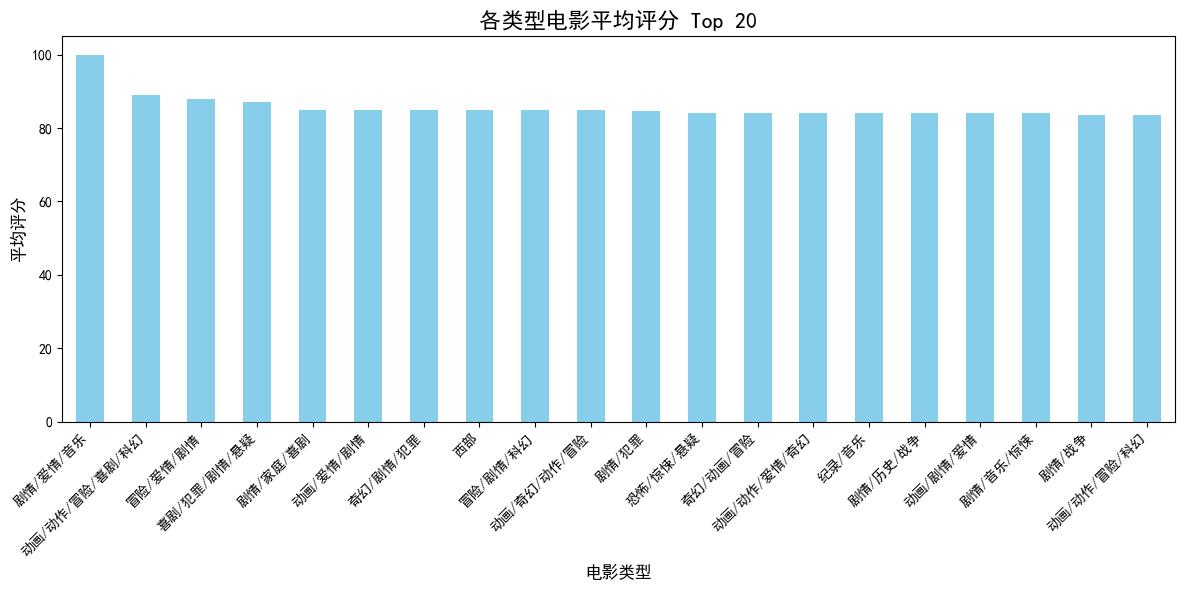

In [53]:
import pandas as pd
import matplotlib.pyplot as plt

#配置项，展示所有 数据
pd.set_option('display.max_columns', None)
df = pd.read_csv('csv_data/movies.csv')
plt.rcParams['font.sans-serif'] = ['SimHei']  # 或 'Microsoft YaHei'
plt.rcParams['axes.unicode_minus'] = False    # 解决负号显示问题
df['score'] = pd.to_numeric(df['score'], errors='coerce')
# 按类型分组，计算平均评分（去除缺失值）
type_avg = df.groupby('类型')['score'].mean().sort_values(ascending=False)
# print(type_avg)
plt.figure(figsize=(12, 6))
type_avg.head(20).plot(kind='bar', color='skyblue')
plt.title('各类型电影平均评分 Top 20', fontsize=16)
plt.xlabel('电影类型', fontsize=12)
plt.ylabel('平均评分', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('data/movies_plot.png',dpi=300)
plt.show()


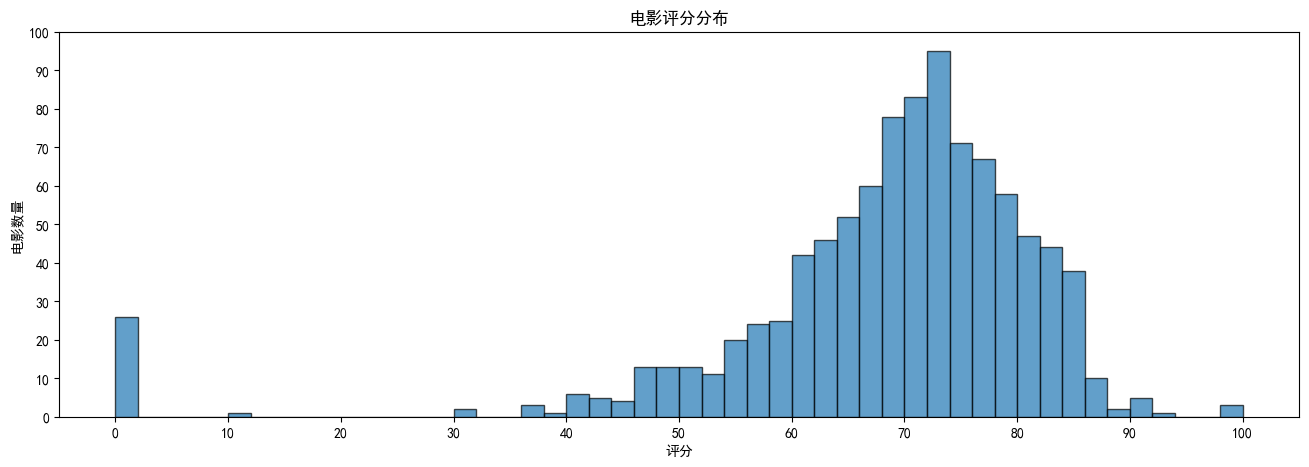

In [54]:
plt.figure(figsize=(16, 5))
plt.hist(df['score'].dropna(), bins=50, edgecolor='black', alpha=0.7)
plt.title('电影评分分布')
plt.xlabel('评分')
plt.ylabel('电影数量')
plt.xticks(range(0, 101, 10))   # 0,10,20,...,100
plt.yticks(range(0, 101, 10))
plt.savefig('data/movies_plot1.png',dpi=300 )
plt.show()



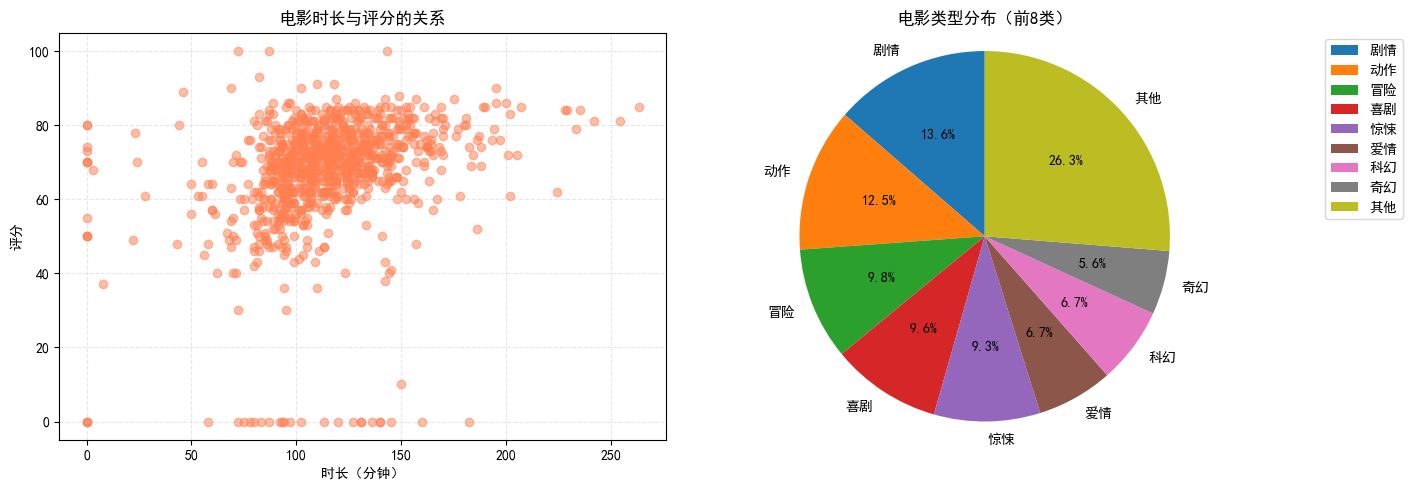

In [55]:
df = pd.read_csv('csv_data/movies.csv')

# 2. 数据清洗
df['score'] = pd.to_numeric(df['score'], errors='coerce')
df['时长'] = pd.to_numeric(df['时长'], errors='coerce')

# 3. 拆分类型列（用于饼图统计）
# 假设原始类型列是 "动作/冒险/科幻" 格式
df['类型'] = df['类型'].fillna('')                      # 填充缺失
df['类型列表'] = df['类型'].str.split('/')              # 转为列表
df_exploded = df.explode('类型列表')                    # 每个类型单独成行
type_counts = df_exploded['类型列表'].value_counts()    # 统计各类型电影数量

# 4. 创建子图布局（1行2列，画布大小适当）
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# ---------- 子图1：散点图（时长 vs 评分）----------
# 删除时长或评分为空的行
scatter_data = df.dropna(subset=['时长', 'score'])
ax1.scatter(scatter_data['时长'], scatter_data['score'], alpha=0.5, color='coral')
ax1.set_title('电影时长与评分的关系')
ax1.set_xlabel('时长（分钟）')
ax1.set_ylabel('评分')
ax1.grid(True, linestyle='--', alpha=0.3)

# ---------- 子图2：饼图（类型分布）----------
# 取前8种类型，其余合并为“其他”
top_n = 8
top_types = type_counts.head(top_n)
others = type_counts.iloc[top_n:].sum()
if others > 0:
    top_types['其他'] = others

# 绘制饼图
ax2.pie(top_types.values, labels=top_types.index, autopct='%1.1f%%', startangle=90)
ax2.set_title(f'电影类型分布（前{top_n}类）')
ax2.axis('equal')   # 使饼图为正圆
ax2.legend(loc='upper right', bbox_to_anchor=(1.2, 1))
plt.tight_layout()
plt.savefig('data/movies_plot2.png',dpi=300 )
plt.show()


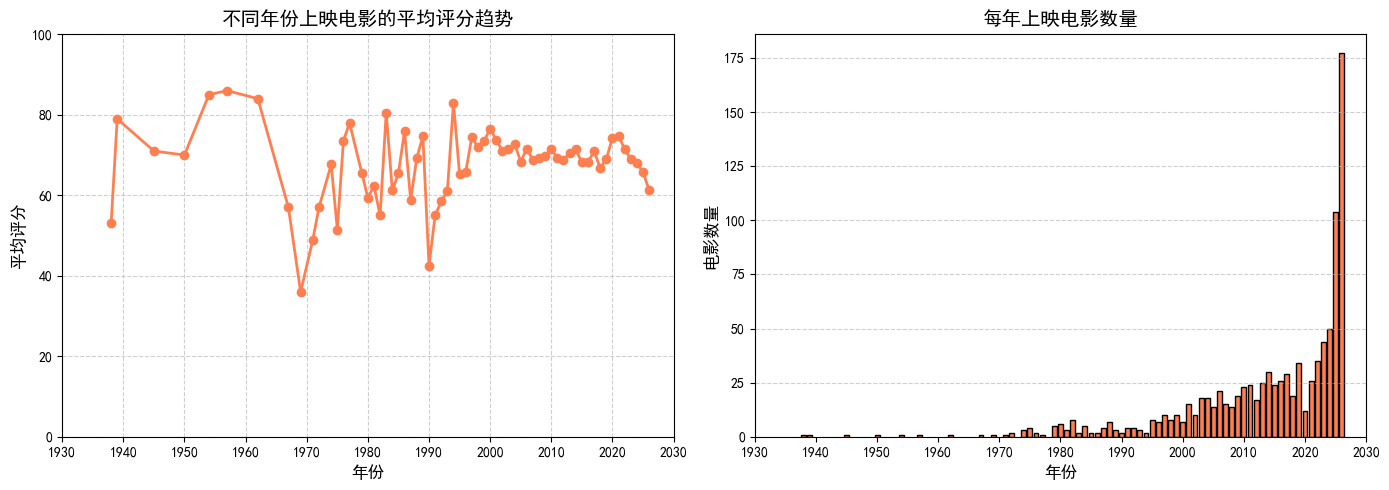

In [56]:
# 1. 读取数据并清洗
df = pd.read_csv('csv_data/movies.csv')
df['上映时间'] = pd.to_datetime(df['上映时间'], errors='coerce')
df['年份'] = df['上映时间'].dt.year
df['score'] = pd.to_numeric(df['score'], errors='coerce')

# 2. 聚合数据
# 2.1 每年平均评分
year_avg = df.groupby('年份')['score'].mean().dropna().sort_index()
# 2.2 每年电影数量（计数）
year_count = df['年份'].value_counts().sort_index()

# 3. 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# 4. 创建子图布局：1行2列，宽度比适当
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# ---------- 子图1：折线图（平均评分趋势） ----------
ax1.plot(year_avg.index, year_avg.values, marker='o', linestyle='-', color='coral', linewidth=2)
ax1.set_title('不同年份上映电影的平均评分趋势', fontsize=14)
ax1.set_xlabel('年份', fontsize=12)
ax1.set_ylabel('平均评分', fontsize=12)
ax1.grid(True, linestyle='--', alpha=0.6)
ax1.set_xticks(range(1930, 2050, 10))
ax1.set_yticks(range(0, 101, 20))
ax1.set_xlim(1930, 2030)   # 根据数据范围调整

# ---------- 子图2：柱状图（每年电影数量） ----------
ax2.bar(year_count.index, year_count.values, width=0.8, color='coral', edgecolor='black')
ax2.set_title('每年上映电影数量', fontsize=14)
ax2.set_xlabel('年份', fontsize=12)
ax2.set_ylabel('电影数量', fontsize=12)
ax2.grid(axis='y', linestyle='--', alpha=0.6)
ax2.set_xticks(range(1930, 2050, 10))
ax2.set_xlim(1930, 2030)

# 自动调整布局，防止重叠
plt.tight_layout()
plt.savefig('data/movies_plot3.png',dpi=300 )
plt.show()


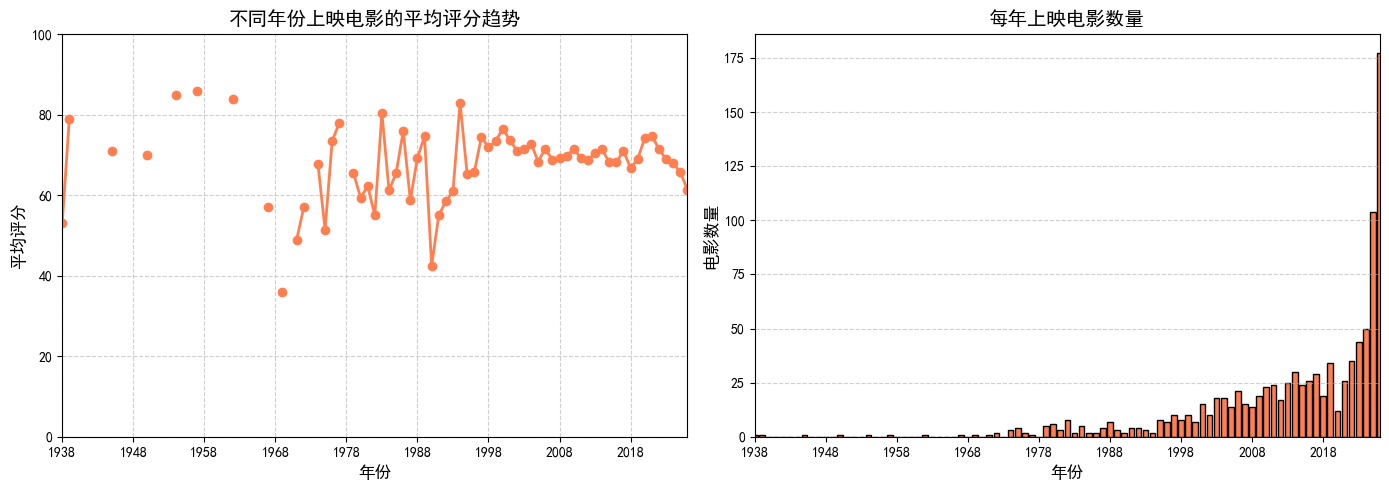

In [57]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. 读取数据并清洗
df = pd.read_csv('csv_data/movies.csv')
df['上映时间'] = pd.to_datetime(df['上映时间'], errors='coerce')
df['年份'] = df['上映时间'].dt.year
df['score'] = pd.to_numeric(df['score'], errors='coerce')

# 2. 聚合原始数据（不连续）
year_avg_raw = df.groupby('年份')['score'].mean().dropna()
year_count_raw = df['年份'].value_counts()

# 2.1 构造连续年份范围（从数据最小年份到最大年份）
min_year = int(df['年份'].min())
max_year = int(df['年份'].max())
all_years = range(min_year, max_year + 1)

# 2.2 重新索引，填充缺失值
year_avg = year_avg_raw.reindex(all_years)                 # 评分用 NaN 填充（缺数据点）
year_count = year_count_raw.reindex(all_years, fill_value=0)  # 数量用 0 填充

# 3. 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# 4. 创建子图布局
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# ---------- 子图1：折线图（平均评分趋势） ----------
# 注意：此时 year_avg 中可能有 NaN，plot 会自动断开
ax1.plot(year_avg.index, year_avg.values, marker='o', linestyle='-', color='coral', linewidth=2)
ax1.set_title('不同年份上映电影的平均评分趋势', fontsize=14)
ax1.set_xlabel('年份', fontsize=12)
ax1.set_ylabel('平均评分', fontsize=12)
ax1.grid(True, linestyle='--', alpha=0.6)
# 根据实际数据范围设置 x 轴刻度
ax1.set_xticks(range(min_year, max_year + 1, 10))
ax1.set_xlim(min_year, max_year)
ax1.set_yticks(range(0, 101, 20))

# ---------- 子图2：柱状图（每年电影数量） ----------
ax2.bar(year_count.index, year_count.values, width=0.8, color='coral', edgecolor='black')
ax2.set_title('每年上映电影数量', fontsize=14)
ax2.set_xlabel('年份', fontsize=12)
ax2.set_ylabel('电影数量', fontsize=12)
ax2.grid(axis='y', linestyle='--', alpha=0.6)
ax2.set_xticks(range(min_year, max_year + 1, 10))
ax2.set_xlim(min_year, max_year)

plt.tight_layout()
plt.savefig('data/movies_plot4.png',dpi=300)
plt.show()
